![image.png](https://i.imgur.com/a3uAqnb.png)

In [1]:
import numpy as np

img = np.array([
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
], dtype=float)

kernel = np.array([
    [ 1, 0,-1],
    [ 1, 0,-1],
    [ 1, 0,-1]
], dtype=float)

def conv2_valid(x, k):
    H, W = x.shape
    kh, kw = k.shape
    out = np.zeros((H-kh+1, W-kw+1), dtype=float)
    for i in range(H-kh+1):
        for j in range(W-kw+1):
            out[i, j] = np.sum(x[i:i+kh, j:j+kw] * k)
    return out

out = conv2_valid(img, kernel)
print(out)

[[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]


In [6]:
import cv2
import numpy as np

gray = cv2.imread("EdgeExample.jpg", cv2.IMREAD_GRAYSCALE)

k = np.array([[ 1, 0,-1],
              [ 1, 0,-1],
              [ 1, 0,-1]], dtype=np.float32)

k1 = np.array([[ 1, 0,-1],
              [ 2, 0,-2],
              [ 1, 0,-1]], dtype=np.float32)

k2 = np.array([[3, 0,-3],
              [ 20, 0,-20],
              [ 3, 0,-3]], dtype=np.float32)

edges_v = cv2.filter2D(gray, ddepth=cv2.CV_32F, kernel=k2)
edges_v = cv2.convertScaleAbs(edges_v)   # to uint8 for viewing

cv2.imwrite("vertical_edges_scharr20.jpg", edges_v)


True

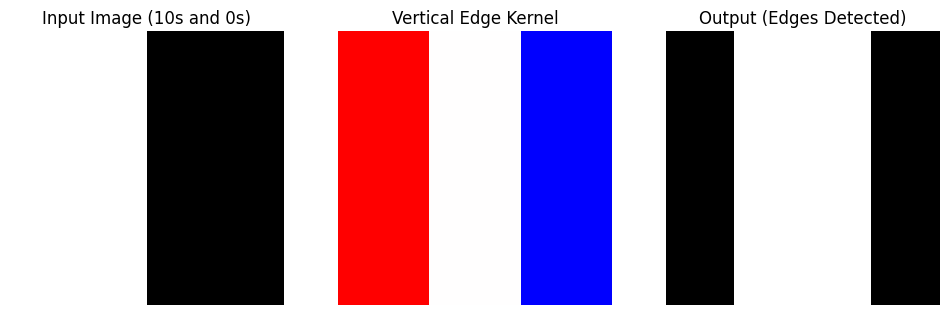

Output matrix:
 [[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array([
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
    [10,10,10,0,0,0],
], dtype=float)

kernel = np.array([
    [ 1, 0,-1],
    [ 1, 0,-1],
    [ 1, 0,-1]
], dtype=float)

def conv2_valid(x, k):
    H, W = x.shape
    kh, kw = k.shape
    out = np.zeros((H-kh+1, W-kw+1), dtype=float)
    for i in range(H-kh+1):
        for j in range(W-kw+1):
            out[i, j] = np.sum(x[i:i+kh, j:j+kw] * k)
    return out

out = conv2_valid(img, kernel)

fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].imshow(img, cmap="gray", vmin=0, vmax=10)
axs[0].set_title("Input Image (10s and 0s)")
axs[0].axis("off")

axs[1].imshow(kernel, cmap="bwr")
axs[1].set_title("Vertical Edge Kernel")
axs[1].axis("off")

axs[2].imshow(out, cmap="gray")
axs[2].set_title("Output (Edges Detected)")
axs[2].axis("off")

plt.show()

print("Output matrix:\n", out)
